# 1、前置说明
 - 标题结构化，层级顺序。

In [29]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
root_dir = r"E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0数据集\00 place-pulse-dataset-images 原始数据集"
dest_dir = os.path.join(root_dir,"01代码运行产生的文件")
if not os.path.exists(dest_dir):
    os.makedirs(dest_dir, exist_ok=True)

# 1. locations.tsv
location_path = os.path.join(root_dir, 'locations.tsv')
locations_df = pd.read_csv(location_path, sep='\t')
print("locations.tsv:",locations_df.columns)
locations_df

locations.tsv: Index(['_id', 'heading', 'loc.0', 'loc.1', 'owner', 'pitch', 'place_id',
       'type', 'votes'],
      dtype='object')


,_id,heading,loc.0,loc.1,owner,pitch,place_id,type,votes
0,50e5f7d4d7c3df413b00056a,0,22.310524,114.170637,deepak.jagdish@gmail.com,0,50e5f7c1d7c3df413b000495,gsv,0
1,50e5f7d4d7c3df413b00056b,0,22.274799,114.192828,deepak.jagdish@gmail.com,0,50e5f7c1d7c3df413b000495,gsv,0
2,50e5f7d4d7c3df413b00056c,0,22.291117,114.147373,deepak.jagdish@gmail.com,0,50e5f7c1d7c3df413b000495,gsv,0
3,50e5f7d4d7c3df413b00056d,0,22.314273,114.177176,deepak.jagdish@gmail.com,0,50e5f7c1d7c3df413b000495,gsv,0
4,50e5f7d4d7c3df413b00056e,0,22.332412,114.204790,deepak.jagdish@gmail.com,0,50e5f7c1d7c3df413b000495,gsv,0
...,...,...,...,...,...,...,...,...,...
111385,5185d534fdc9f03fd500148f,0,45.591299,-73.520681,deepak.jagdish@gmail.com,0,50f38816fdc9f065f0000364,gsv,0
111386,5185d534fdc9f03fd5001490,0,45.470656,-73.631901,deepak.jagdish@gmail.com,0,50f38816fdc9f065f0000364,gsv,0
111387,5185d536fdc9f03fd5001491,0,45.626787,-73.547511,deepak.jagdish@gmail.com,0,50f38816fdc9f065f0000364,gsv,0
111388,5185d539fdc9f03fd5001492,0,45.526637,-73.593872,deepak.jagdish@gmail.com,0,50f38816fdc9f065f0000364,gsv,0


In [31]:
# locations_df['place_id'].unique()
locations_df['_id'].unique()

array(['50e5f7d4d7c3df413b00056a', '50e5f7d4d7c3df413b00056b',
       '50e5f7d4d7c3df413b00056c', ..., '5185d536fdc9f03fd5001491',
       '5185d539fdc9f03fd5001492', '5185d53bfdc9f03fd5001493'],
      dtype=object)

In [32]:
locations_df = locations_df[['_id','place_id']]
locations_df

,_id,place_id
0,50e5f7d4d7c3df413b00056a,50e5f7c1d7c3df413b000495
1,50e5f7d4d7c3df413b00056b,50e5f7c1d7c3df413b000495
2,50e5f7d4d7c3df413b00056c,50e5f7c1d7c3df413b000495
3,50e5f7d4d7c3df413b00056d,50e5f7c1d7c3df413b000495
4,50e5f7d4d7c3df413b00056e,50e5f7c1d7c3df413b000495
...,...,...
111385,5185d534fdc9f03fd500148f,50f38816fdc9f065f0000364
111386,5185d534fdc9f03fd5001490,50f38816fdc9f065f0000364
111387,5185d536fdc9f03fd5001491,50f38816fdc9f065f0000364
111388,5185d539fdc9f03fd5001492,50f38816fdc9f065f0000364


In [33]:
temp_df = locations_df
temp_df

,_id,place_id
0,50e5f7d4d7c3df413b00056a,50e5f7c1d7c3df413b000495
1,50e5f7d4d7c3df413b00056b,50e5f7c1d7c3df413b000495
2,50e5f7d4d7c3df413b00056c,50e5f7c1d7c3df413b000495
3,50e5f7d4d7c3df413b00056d,50e5f7c1d7c3df413b000495
4,50e5f7d4d7c3df413b00056e,50e5f7c1d7c3df413b000495
...,...,...
111385,5185d534fdc9f03fd500148f,50f38816fdc9f065f0000364
111386,5185d534fdc9f03fd5001490,50f38816fdc9f065f0000364
111387,5185d536fdc9f03fd5001491,50f38816fdc9f065f0000364
111388,5185d539fdc9f03fd5001492,50f38816fdc9f065f0000364


In [34]:
# 2. places.tsv
places_path = os.path.join(root_dir, 'places.tsv')
places_df = pd.read_csv(places_path, sep='\t')
print("places.tsv:",places_df.columns)
places_df.head(100)

places.tsv: Index(['_id', 'data_resolution', 'location_distribution', 'owner',
       'place_name', 'polygon'],
      dtype='object')


,_id,data_resolution,location_distribution,owner,place_name,polygon
0,50e5e9c1d7c3df413b000000,500,randomly,deepak.jagdish@gmail.com,Amsterdam,"4.840850830078125,52.373083994540266,4.8429107..."
1,50e5ec46d7c3df413b000062,500,randomly,deepak.jagdish@gmail.com,Barcelona,"2.297515869140625,41.47771800887873,2.25082397..."
2,50e5ef31d7c3df413b000178,500,randomly,deepak.jagdish@gmail.com,Belo Horizonte,"-44.051055908203125,-19.91202911100831,-44.053..."
3,50e5f168d7c3df413b000279,500,randomly,deepak.jagdish@gmail.com,Boston,"-71.18728637695312,42.377314613944506,-71.1769..."
4,50e5f30fd7c3df413b000303,1000,randomly,deepak.jagdish@gmail.com,Chicago,"-87.71621704101562,41.74160260664951,-87.54455..."
5,50e5f69ed7c3df413b000377,500,randomly,deepak.jagdish@gmail.com,Denver,"-104.86518859863281,39.776880380637024,-105.11..."
6,50e5f7c1d7c3df413b000495,250,randomly,deepak.jagdish@gmail.com,Hong Kong,"114.12220001220703,22.326576489662482,114.1287..."
7,50e5f937d7c3df413b0005b3,500,randomly,deepak.jagdish@gmail.com,Kiev,"30.60516357421875,50.49595785216966,30.5186462..."
8,50e5fad8d7c3df413b00063c,250,randomly,deepak.jagdish@gmail.com,Kyoto,"135.81024169921875,35.05922870088872,135.79719..."
9,50e5fc32d7c3df413b000788,500,randomly,deepak.jagdish@gmail.com,Lisbon,"-9.0802001953125,38.84559050700921,-9.09805297..."


In [35]:
places_df['_id'].unique()   #这里的_id就是地名的id，真无语，用_id,为何不干脆直接使用place_id

array(['50e5e9c1d7c3df413b000000', '50e5ec46d7c3df413b000062',
       '50e5ef31d7c3df413b000178', '50e5f168d7c3df413b000279',
       '50e5f30fd7c3df413b000303', '50e5f69ed7c3df413b000377',
       '50e5f7c1d7c3df413b000495', '50e5f937d7c3df413b0005b3',
       '50e5fad8d7c3df413b00063c', '50e5fc32d7c3df413b000788',
       '50e5fdeed7c3df413b000899', '50e5ff26d7c3df413b000902',
       '50e6f9cdd7c3df413b0009cf', '50e6fcabd7c3df413b000aa6',
       '50e6fdcdd7c3df413b000b08', '50e6feb9d7c3df413b000b64',
       '50e700fdd7c3df413b000bdb', '50e70a8cd7c3df413b000c72',
       '50e7316dd7c3df413b000d04', '50e73270d7c3df413b000d8c',
       '50e733f0d7c3df413b000e41', '50e734e9d7c3df413b000ebf',
       '50e735e8d7c3df413b000f54', '50e73766d7c3df413b00103f',
       '50e73a60d7c3df413b0010cc', '50e743a7d7c3df413b001136',
       '50e745a4d7c3df413b00127a', '50e748dbd7c3df413b0012f5',
       '50e74a36d7c3df413b001488', '50e7509bd7c3df413b00157e',
       '50e751ded7c3df413b001609', '50e752cdd7c3df413b0

In [36]:
places_df = places_df[['_id','place_name']]
places_df

,_id,place_name
0,50e5e9c1d7c3df413b000000,Amsterdam
1,50e5ec46d7c3df413b000062,Barcelona
2,50e5ef31d7c3df413b000178,Belo Horizonte
3,50e5f168d7c3df413b000279,Boston
4,50e5f30fd7c3df413b000303,Chicago
5,50e5f69ed7c3df413b000377,Denver
6,50e5f7c1d7c3df413b000495,Hong Kong
7,50e5f937d7c3df413b0005b3,Kiev
8,50e5fad8d7c3df413b00063c,Kyoto
9,50e5fc32d7c3df413b000788,Lisbon


In [37]:
temp_df = temp_df.merge(places_df,left_on='place_id',right_on='_id')
temp_df

,_id_x,place_id,_id_y,place_name
0,50e5f7d4d7c3df413b00056a,50e5f7c1d7c3df413b000495,50e5f7c1d7c3df413b000495,Hong Kong
1,50e5f7d4d7c3df413b00056b,50e5f7c1d7c3df413b000495,50e5f7c1d7c3df413b000495,Hong Kong
2,50e5f7d4d7c3df413b00056c,50e5f7c1d7c3df413b000495,50e5f7c1d7c3df413b000495,Hong Kong
3,50e5f7d4d7c3df413b00056d,50e5f7c1d7c3df413b000495,50e5f7c1d7c3df413b000495,Hong Kong
4,50e5f7d4d7c3df413b00056e,50e5f7c1d7c3df413b000495,50e5f7c1d7c3df413b000495,Hong Kong
...,...,...,...,...
111385,5185d534fdc9f03fd500148f,50f38816fdc9f065f0000364,50f38816fdc9f065f0000364,Montreal
111386,5185d534fdc9f03fd5001490,50f38816fdc9f065f0000364,50f38816fdc9f065f0000364,Montreal
111387,5185d536fdc9f03fd5001491,50f38816fdc9f065f0000364,50f38816fdc9f065f0000364,Montreal
111388,5185d539fdc9f03fd5001492,50f38816fdc9f065f0000364,50f38816fdc9f065f0000364,Montreal


### 总结：命名规律，这个文件的_id，对应其他文件中列"文件名_id"

# 2.核心部分（qscores.tsv、studies.tsv、votes.tsv）

In [38]:
# 3. qscores.tsv
qscores_path = os.path.join(root_dir, 'qscores.tsv')
qscores_df = pd.read_csv(qscores_path, sep='\t')
print("qscores.tsv:",qscores_df.columns)
qscores_df

qscores.tsv: Index(['_id', 'location_id', 'num_votes', 'place_id', 'study_id',
       'trueskill.score', 'trueskill.stds.-1'],
      dtype='object')


,_id,location_id,num_votes,place_id,study_id,trueskill.score,trueskill.stds.-1
0,51e048d4fdc9f01d25aab793,5185d46bfdc9f03fd50013d5,5,50f38816fdc9f065f0000364,50f62cb7a84ea7c5fdd2e458,36.502702,4.724535
1,51e048c9fdc9f01d25a9a084,513cbed8fdc9f035870011fe,2,50e5f30fd7c3df413b000303,50f62cb7a84ea7c5fdd2e458,32.762342,6.070995
2,51e048a7fdc9f01d25a67f6e,513e5fd7fdc9f0358700b2d7,4,50e6fcabd7c3df413b000aa6,50f62c41a84ea7c5fdd2e454,26.115423,4.384154
3,5217c360ad93a7d3e7b1d181,50f5eaf6fdc9f065f0007ef8,6,50f38e44fdc9f065f0000855,5217c351ad93a7d3e7b07a64,17.800618,4.003182
4,51e0489dfdc9f01d25a59df7,5185d4defdc9f03fd500143b,6,50f38816fdc9f065f0000364,50a68a51fdc9f05596000002,12.561016,3.885248
...,...,...,...,...,...,...,...
665923,51e048acfdc9f01d25a6f6a5,513cdb38fdc9f03587002037,13,50e745a4d7c3df413b00127a,50f62c41a84ea7c5fdd2e454,27.128087,2.505120
665924,51e048abfdc9f01d25a6d52c,5140cc05fdc9f04926002cce,9,50e735e8d7c3df413b000f54,50f62c41a84ea7c5fdd2e454,25.036504,3.157734
665925,51e048a1fdc9f01d25a60099,50f43b71fdc9f065f00030d3,10,50f39725fdc9f065f0000c38,50a68a51fdc9f05596000002,24.235321,3.141033
665926,51e048a0fdc9f01d25a5dbb6,50f5e701fdc9f065f0006f04,15,50f39092fdc9f065f000097d,50a68a51fdc9f05596000002,17.335245,2.468244


In [39]:
# qscores_df['_id'].unique()
# qscores_df['location_id'].unique()
# qscores_df['study_id'].unique()
# qscores_df['place_id'].unique()

In [40]:
# qscores_df = qscores_df.drop(columns=['location_id','place_id'])
qscores_df = qscores_df[['location_id', 'num_votes', 'study_id','trueskill.score', 'trueskill.stds.-1']]
qscores_df

,location_id,num_votes,study_id,trueskill.score,trueskill.stds.-1
0,5185d46bfdc9f03fd50013d5,5,50f62cb7a84ea7c5fdd2e458,36.502702,4.724535
1,513cbed8fdc9f035870011fe,2,50f62cb7a84ea7c5fdd2e458,32.762342,6.070995
2,513e5fd7fdc9f0358700b2d7,4,50f62c41a84ea7c5fdd2e454,26.115423,4.384154
3,50f5eaf6fdc9f065f0007ef8,6,5217c351ad93a7d3e7b07a64,17.800618,4.003182
4,5185d4defdc9f03fd500143b,6,50a68a51fdc9f05596000002,12.561016,3.885248
...,...,...,...,...,...
665923,513cdb38fdc9f03587002037,13,50f62c41a84ea7c5fdd2e454,27.128087,2.505120
665924,5140cc05fdc9f04926002cce,9,50f62c41a84ea7c5fdd2e454,25.036504,3.157734
665925,50f43b71fdc9f065f00030d3,10,50a68a51fdc9f05596000002,24.235321,3.141033
665926,50f5e701fdc9f065f0006f04,15,50a68a51fdc9f05596000002,17.335245,2.468244


In [41]:
merge_df = qscores_df
merge_df

,location_id,num_votes,study_id,trueskill.score,trueskill.stds.-1
0,5185d46bfdc9f03fd50013d5,5,50f62cb7a84ea7c5fdd2e458,36.502702,4.724535
1,513cbed8fdc9f035870011fe,2,50f62cb7a84ea7c5fdd2e458,32.762342,6.070995
2,513e5fd7fdc9f0358700b2d7,4,50f62c41a84ea7c5fdd2e454,26.115423,4.384154
3,50f5eaf6fdc9f065f0007ef8,6,5217c351ad93a7d3e7b07a64,17.800618,4.003182
4,5185d4defdc9f03fd500143b,6,50a68a51fdc9f05596000002,12.561016,3.885248
...,...,...,...,...,...
665923,513cdb38fdc9f03587002037,13,50f62c41a84ea7c5fdd2e454,27.128087,2.505120
665924,5140cc05fdc9f04926002cce,9,50f62c41a84ea7c5fdd2e454,25.036504,3.157734
665925,50f43b71fdc9f065f00030d3,10,50a68a51fdc9f05596000002,24.235321,3.141033
665926,50f5e701fdc9f065f0006f04,15,50a68a51fdc9f05596000002,17.335245,2.468244


In [42]:
# 4. studies.tsv
studies_path = os.path.join(root_dir, 'studies.tsv')
studies_df = pd.read_csv(studies_path, sep='\t')
print("studies.tsv:",studies_df.columns)
studies_df

studies.tsv: Index(['_id', 'num_votes', 'owner', 'study_name', 'study_public',
       'study_question'],
      dtype='object')


,_id,num_votes,owner,study_name,study_public,study_question
0,50a68a51fdc9f05596000002,511037,deepak.jagdish@gmail.com,safer_multicity,yes,safer
1,50f62c41a84ea7c5fdd2e454,367476,deepak.jagdish@gmail.com,livelier_multicity,yes,livelier
2,50f62c68a84ea7c5fdd2e456,144068,deepak.jagdish@gmail.com,cleaner_multicity,yes,more boring
3,50f62cb7a84ea7c5fdd2e458,174784,deepak.jagdish@gmail.com,wealthy_multicity,yes,wealthier
4,50f62ccfa84ea7c5fdd2e459,149361,deepak.jagdish@gmail.com,depressing_multicity,yes,more depressing
5,5217c351ad93a7d3e7b07a64,220656,deepak.jagdish@gmail.com,more beautiful,yes,more beautiful


In [43]:
studies_df = studies_df[['_id','study_question']]
studies_df

,_id,study_question
0,50a68a51fdc9f05596000002,safer
1,50f62c41a84ea7c5fdd2e454,livelier
2,50f62c68a84ea7c5fdd2e456,more boring
3,50f62cb7a84ea7c5fdd2e458,wealthier
4,50f62ccfa84ea7c5fdd2e459,more depressing
5,5217c351ad93a7d3e7b07a64,more beautiful


In [44]:
merge_df = merge_df.merge(studies_df,left_on='study_id',right_on='_id')
print(merge_df.columns)
merge_df

Index(['location_id', 'num_votes', 'study_id', 'trueskill.score',
       'trueskill.stds.-1', '_id', 'study_question'],
      dtype='object')


,location_id,num_votes,study_id,trueskill.score,trueskill.stds.-1,_id,study_question
0,5185d46bfdc9f03fd50013d5,5,50f62cb7a84ea7c5fdd2e458,36.502702,4.724535,50f62cb7a84ea7c5fdd2e458,wealthier
1,513cbed8fdc9f035870011fe,2,50f62cb7a84ea7c5fdd2e458,32.762342,6.070995,50f62cb7a84ea7c5fdd2e458,wealthier
2,513e5fd7fdc9f0358700b2d7,4,50f62c41a84ea7c5fdd2e454,26.115423,4.384154,50f62c41a84ea7c5fdd2e454,livelier
3,50f5eaf6fdc9f065f0007ef8,6,5217c351ad93a7d3e7b07a64,17.800618,4.003182,5217c351ad93a7d3e7b07a64,more beautiful
4,5185d4defdc9f03fd500143b,6,50a68a51fdc9f05596000002,12.561016,3.885248,50a68a51fdc9f05596000002,safer
...,...,...,...,...,...,...,...
665923,513cdb38fdc9f03587002037,13,50f62c41a84ea7c5fdd2e454,27.128087,2.505120,50f62c41a84ea7c5fdd2e454,livelier
665924,5140cc05fdc9f04926002cce,9,50f62c41a84ea7c5fdd2e454,25.036504,3.157734,50f62c41a84ea7c5fdd2e454,livelier
665925,50f43b71fdc9f065f00030d3,10,50a68a51fdc9f05596000002,24.235321,3.141033,50a68a51fdc9f05596000002,safer
665926,50f5e701fdc9f065f0006f04,15,50a68a51fdc9f05596000002,17.335245,2.468244,50a68a51fdc9f05596000002,safer


In [45]:
# merge_df = merge_df.drop(columns=['_id_y', 'study_id'])
merge_df = merge_df[['location_id', 'num_votes', 'trueskill.score','trueskill.stds.-1', 'study_question']]
merge_df

,location_id,num_votes,trueskill.score,trueskill.stds.-1,study_question
0,5185d46bfdc9f03fd50013d5,5,36.502702,4.724535,wealthier
1,513cbed8fdc9f035870011fe,2,32.762342,6.070995,wealthier
2,513e5fd7fdc9f0358700b2d7,4,26.115423,4.384154,livelier
3,50f5eaf6fdc9f065f0007ef8,6,17.800618,4.003182,more beautiful
4,5185d4defdc9f03fd500143b,6,12.561016,3.885248,safer
...,...,...,...,...,...
665923,513cdb38fdc9f03587002037,13,27.128087,2.505120,livelier
665924,5140cc05fdc9f04926002cce,9,25.036504,3.157734,livelier
665925,50f43b71fdc9f065f00030d3,10,24.235321,3.141033,safer
665926,50f5e701fdc9f065f0006f04,15,17.335245,2.468244,safer


### trueskill.score归一化
### 这里的归一化也要看清你是针对某个维度的数据还是针对于所有维度的数据进行归一化，这里我是针对每个维度的数据。
1、如果不进行任何筛选，那就是每个维度所有的数据进行归一化。
2、但是当筛选>=12的数据时，那就是每个维度>=12的数据进行归一化。
3、两个归一化中，最大最小值可能是一样的，也有小概率不一样!！！当最大最小值不一样时，结果也不一样，所以用哪些数据进行归一化自己要想清楚。

In [46]:
def normalize_group(df, target_min=0, target_max=10):
    min_val = df['trueskill.score'].min()
    max_val = df['trueskill.score'].max()
    study_question = df['study_question'].unique()  # 取当前分组的名称
    print(f"维度：{study_question}，最小值：{min_val}，最大值：{max_val}")
    if min_val == max_val:
        df['trueskill_norm'] = target_min  # 避免除以0，全部设为下限
    else:
        df['trueskill_norm'] = (
            (df['trueskill.score'] - min_val) / (max_val - min_val)
        ) * (target_max - target_min) + target_min
    return df

# 应用归一化
merge_df = merge_df.groupby('study_question', group_keys=False).apply(normalize_group)

维度：['livelier']，最小值：7.12442806957，最大值：43.1962918294
维度：['more beautiful']，最小值：7.98683470882，最大值：42.4965406664
维度：['more boring']，最小值：8.40971464446，最大值：43.4406335024
维度：['more depressing']，最小值：9.11606072292，最大值：44.5623150337
维度：['safer']，最小值：6.41296145555，最大值：42.3179518992
维度：['wealthier']，最小值：8.72681961213，最大值：44.5098963901


C:\Users\Ryota\AppData\Local\Temp\ipykernel_28624\4074679217.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merge_df = merge_df.groupby('study_question', group_keys=False).apply(normalize_group)


In [47]:
merge_df['trueskill_norm'] = merge_df['trueskill_norm'].round(2)
merge_df

,location_id,num_votes,trueskill.score,trueskill.stds.-1,study_question,trueskill_norm
0,5185d46bfdc9f03fd50013d5,5,36.502702,4.724535,wealthier,7.76
1,513cbed8fdc9f035870011fe,2,32.762342,6.070995,wealthier,6.72
2,513e5fd7fdc9f0358700b2d7,4,26.115423,4.384154,livelier,5.26
3,50f5eaf6fdc9f065f0007ef8,6,17.800618,4.003182,more beautiful,2.84
4,5185d4defdc9f03fd500143b,6,12.561016,3.885248,safer,1.71
...,...,...,...,...,...,...
665923,513cdb38fdc9f03587002037,13,27.128087,2.505120,livelier,5.55
665924,5140cc05fdc9f04926002cce,9,25.036504,3.157734,livelier,4.97
665925,50f43b71fdc9f065f00030d3,10,24.235321,3.141033,safer,4.96
665926,50f5e701fdc9f065f0006f04,15,17.335245,2.468244,safer,3.04


In [48]:
merge_df.groupby(by='study_question').size()

study_question
livelier           110988
more beautiful     110988
more boring        110988
more depressing    110988
safer              110988
wealthier          110988
dtype: int64

In [49]:
merge_df.loc[merge_df['location_id'] == '5185d46bfdc9f03fd50013d5']

,location_id,num_votes,trueskill.score,trueskill.stds.-1,study_question,trueskill_norm
0,5185d46bfdc9f03fd50013d5,5,36.502702,4.724535,wealthier,7.76
101907,5185d46bfdc9f03fd50013d5,4,25.314342,4.634233,more depressing,4.57
126518,5185d46bfdc9f03fd50013d5,5,27.421300,4.150751,more beautiful,5.63
349645,5185d46bfdc9f03fd50013d5,6,25.489861,3.726606,livelier,5.09
441406,5185d46bfdc9f03fd50013d5,10,24.699490,2.979138,safer,5.09
580951,5185d46bfdc9f03fd50013d5,1,25.000000,6.474365,more boring,4.74


In [50]:
merge_df.to_csv(os.path.join(dest_dir,"01CSV合并简化后的trueskill评分.csv"), index = False)

# 3.只筛选大于等于某个次数的数据

In [51]:
merge_df

,location_id,num_votes,trueskill.score,trueskill.stds.-1,study_question,trueskill_norm
0,5185d46bfdc9f03fd50013d5,5,36.502702,4.724535,wealthier,7.76
1,513cbed8fdc9f035870011fe,2,32.762342,6.070995,wealthier,6.72
2,513e5fd7fdc9f0358700b2d7,4,26.115423,4.384154,livelier,5.26
3,50f5eaf6fdc9f065f0007ef8,6,17.800618,4.003182,more beautiful,2.84
4,5185d4defdc9f03fd500143b,6,12.561016,3.885248,safer,1.71
...,...,...,...,...,...,...
665923,513cdb38fdc9f03587002037,13,27.128087,2.505120,livelier,5.55
665924,5140cc05fdc9f04926002cce,9,25.036504,3.157734,livelier,4.97
665925,50f43b71fdc9f065f00030d3,10,24.235321,3.141033,safer,4.96
665926,50f5e701fdc9f065f0006f04,15,17.335245,2.468244,safer,3.04


In [52]:
min_votes = 12  # 设置投票数的最小阈值

merge_df_min_votes = merge_df[merge_df['num_votes'] >= min_votes]
merge_df_min_votes

,location_id,num_votes,trueskill.score,trueskill.stds.-1,study_question,trueskill_norm
62,50f5ed6bfdc9f065f0008d66,12,24.676069,2.710604,safer,5.09
459,513d6884fdc9f035870043d4,12,12.047625,3.359033,safer,1.57
754,51413a77fdc9f049260056fd,13,23.609111,2.405731,safer,4.79
998,51414819fdc9f04926006bef,13,25.221061,2.365449,safer,5.24
1003,51414f24fdc9f04926007a0a,12,30.877857,2.856902,livelier,6.59
...,...,...,...,...,...,...
665916,50f44859fdc9f065f0003ee1,14,29.412014,2.494204,safer,6.41
665917,50e5faecd7c3df413b00075a,19,18.625600,2.086014,safer,3.40
665918,513d5787fdc9f0358700319e,14,20.646238,2.397467,safer,3.96
665923,513cdb38fdc9f03587002037,13,27.128087,2.505120,livelier,5.55


In [53]:
def normalize_group(df, target_min=0, target_max=10):
    min_val = df['trueskill.score'].min()
    max_val = df['trueskill.score'].max()
    study_question = df['study_question'].unique()  # 取当前分组的名称
    print(f"维度：{study_question}，最小值：{min_val}，最大值：{max_val}")
    if min_val == max_val:
        df['trueskill_norm'] = target_min  # 避免除以0，全部设为下限
    else:
        df['trueskill_norm'] = (
            (df['trueskill.score'] - min_val) / (max_val - min_val)
        ) * (target_max - target_min) + target_min
    return df

# 应用归一化
merge_df_min_votes = merge_df_min_votes.groupby('study_question', group_keys=False).apply(normalize_group)

维度：['livelier']，最小值：7.12442806957，最大值：42.6357828727
维度：['more beautiful']，最小值：10.3401610094，最大值：38.8305624455
维度：['more boring']，最小值：11.2341611405，最大值：43.4406335024
维度：['more depressing']，最小值：9.44535251447，最大值：43.5756317953
维度：['safer']，最小值：6.41296145555，最大值：42.3179518992
维度：['wealthier']，最小值：8.72681961213，最大值：38.9026156436


C:\Users\Ryota\AppData\Local\Temp\ipykernel_28624\168375150.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merge_df_min_votes = merge_df_min_votes.groupby('study_question', group_keys=False).apply(normalize_group)


In [54]:
merge_df_min_votes.groupby(by='study_question').size()

study_question
livelier           10149
more beautiful       197
more boring          167
more depressing      311
safer              36783
wealthier            535
dtype: int64

已保存: E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0数据集\00 place-pulse-dataset-images 原始数据集\01代码运行产生的文件\02对比次数大于等于12的livelier维度数据.csv

[livelier] 的 trueskill.score 描述性统计：
count    10149.000000
mean        25.163980
std          4.750060
min          7.124428
25%         22.004134
50%         25.177308
75%         28.344520
max         42.635783
Name: trueskill.score, dtype: float64
直方图已保存: E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0数据集\00 place-pulse-dataset-images 原始数据集\01代码运行产生的文件\03对比次数大于等于12的livelier_hist.png
已保存: E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0数据集\00 place-pulse-dataset-images 原始数据集\01代码运行产生的文件\02对比次数大于等于12的more beautiful维度数据.csv

[more beautiful] 的 trueskill.score 描述性统计：
count    197.000000
mean      25.567070
std        6.052188
min       10.340161
25%       21.940382
50%       25.419959
75%       29.676205
max       38.830562
Name: trueskill.score, dtype: float64
直方图已保存: E:\01_UCL\08_Dissertation\01_DataCollection\01

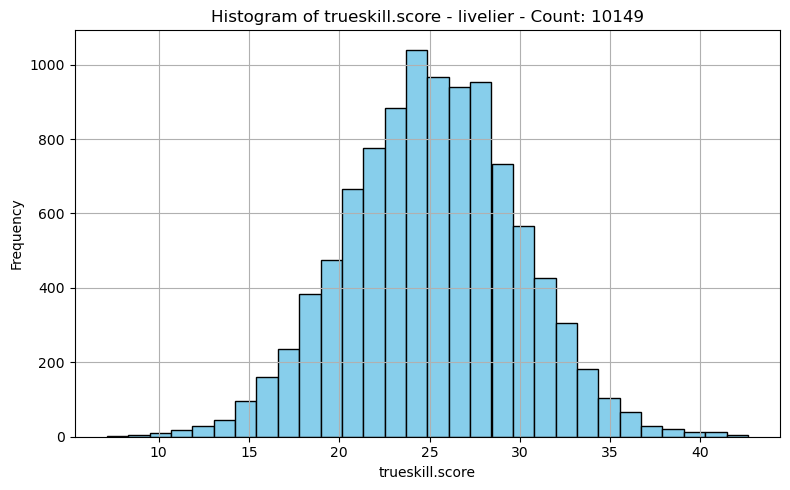

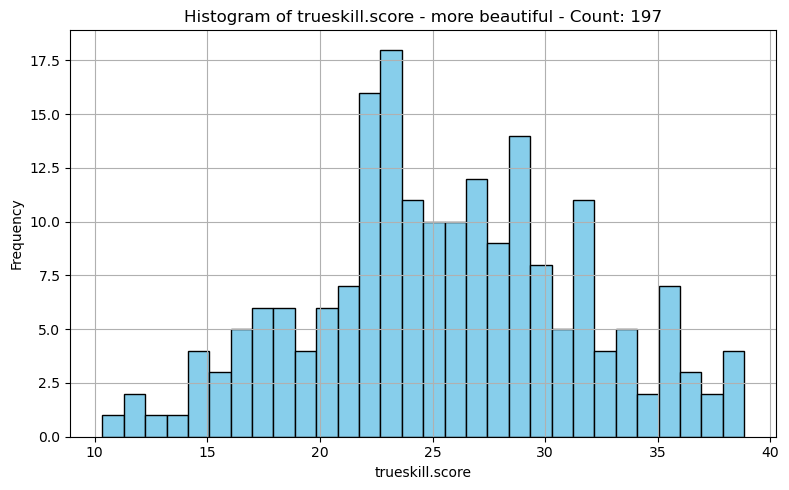

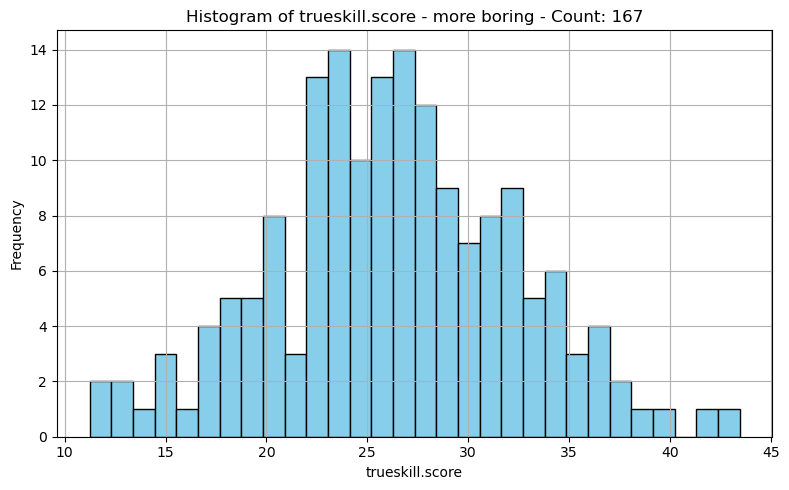

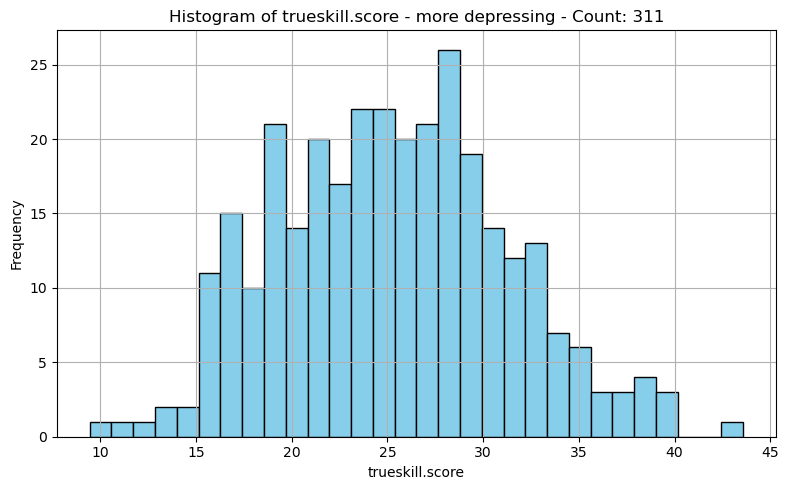

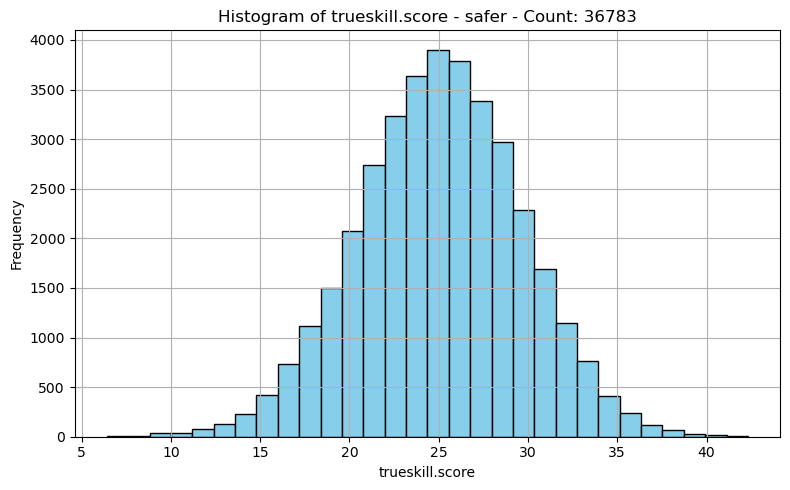

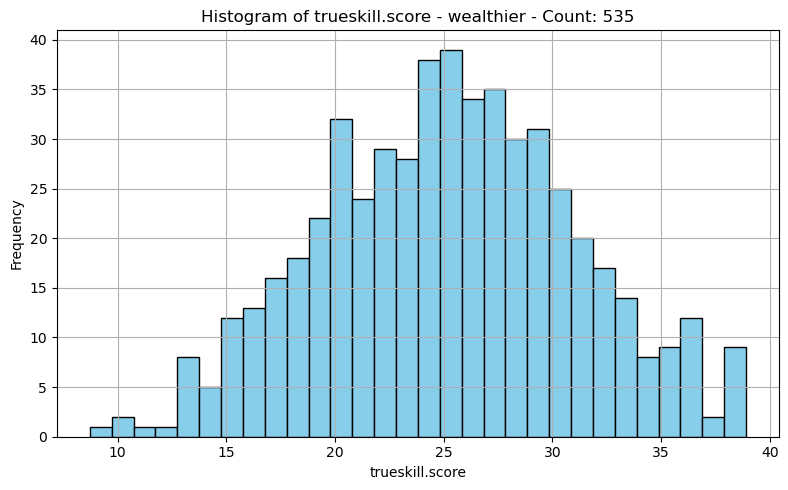

In [55]:
import matplotlib.pyplot as plt
# 遍历每个 study_question 的分组并保存
for question, group_df in merge_df_min_votes.groupby('study_question'):
    # ==== 保存 CSV ====
    filename = f"02对比次数大于等于{min_votes}的{question}维度数据.csv"
    file_path = os.path.join(dest_dir, filename)
    group_df.to_csv(file_path, index=False, encoding='utf-8-sig')
    print(f"已保存: {file_path}")

    # ==== 输出描述性统计信息 ====
    print(f"\n[{question}] 的 trueskill.score 描述性统计：")
    print(group_df['trueskill.score'].describe())

    # ==== 绘制直方图 ====
    plt.figure(figsize=(8, 5))
    plt.hist(group_df['trueskill.score'].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of trueskill.score - {question} - Count: {len(group_df)}")
    plt.xlabel('trueskill.score')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()

    # 保存直方图
    hist_path = os.path.join(dest_dir, f"03对比次数大于等于{min_votes}的{question}_hist.png")
    plt.savefig(hist_path,dpi = 600)
    # plt.close()
    print(f"直方图已保存: {hist_path}")

# 4.筛选每个采样点，每个维度都大于等于某个数值的所有街景图片，没有数据满足，所以用一个模型是不合理的。

In [56]:
# 第一步：统计每个 location_id 的出现次数
location_counts = merge_df_min_votes['location_id'].value_counts()
location_counts

location_id
51413a34fdc9f0492600565c    3
50f43477fdc9f065f000281c    3
51413879fdc9f04926005219    3
50f5ec40fdc9f065f00088b0    3
50f55dd9fdc9f065f00049d9    3
                           ..
50f433c1fdc9f065f000261c    1
50f44859fdc9f065f0003ee1    1
50e5faecd7c3df413b00075a    1
513d5787fdc9f0358700319e    1
5140da0afdc9f04926003d2a    1
Name: count, Length: 44306, dtype: int64

In [57]:
# 第二步：筛选出出现次数为 6 的 location_id
location_ids_6 = location_counts[location_counts == 6].index
location_ids_6

Index([], dtype='object', name='location_id')

In [58]:
# 第三步：从原始数据中筛选这些 location_id 对应的所有行
filtered_df = merge_df_min_votes[merge_df_min_votes['location_id'].isin(location_ids_6)]
filtered_df

,location_id,num_votes,trueskill.score,trueskill.stds.-1,study_question,trueskill_norm


### 归一化代码略

In [59]:
filtered_df.to_csv(os.path.join(dest_dir,f"04每个街景图片6个维度的对比次数都大于等于{min_votes}的数据.csv"),index=False)

In [60]:
# 5. votes.tsv
votes_path = os.path.join(root_dir, 'votes.tsv')
votes_df = pd.read_csv(votes_path, sep='\t')
print("votes.tsv:",votes_df.columns)
votes_df

votes.tsv: Index(['_id', 'choice', 'left', 'right', 'study_id', 'timestamp',
       'voter_uniqueid'],
      dtype='object')


,_id,choice,left,right,study_id,timestamp,voter_uniqueid
0,51a5050aad93a7126ebf218d,left,513d2dbefdc9f03587002515,51413b2ffdc9f049260058ca,50f62cb7a84ea7c5fdd2e458,2013-05-28 15:27:06.914000,efff904a13294553b73ccebd2b1d2ee1
1,51a5052cad93a7126ebf218e,equal,513d7e23fdc9f0358700733a,513d7ac3fdc9f0358700693f,50f62ccfa84ea7c5fdd2e459,2013-05-28 15:27:40.527000,efff904a13294553b73ccebd2b1d2ee1
2,51a50531ad93a7126ebf218f,right,50f60c4dbeb2fed91000028d,513cb652fdc9f03587000a1e,50f62ccfa84ea7c5fdd2e459,2013-05-28 15:27:45.477000,efff904a13294553b73ccebd2b1d2ee1
3,51a50534ad93a7126ebf2190,left,513d9ff9fdc9f0358700887c,513cd544fdc9f03587001efc,50f62ccfa84ea7c5fdd2e459,2013-05-28 15:27:48.638000,efff904a13294553b73ccebd2b1d2ee1
4,51a50a5cad93a7140381df24,left,513f320cfdc9f0358700e030,513cc3acfdc9f035870016c3,50a68a51fdc9f05596000002,2013-05-28 15:49:48.415000,efff904a13294553b73ccebd2b1d2ee1
...,...,...,...,...,...,...,...
1555546,5b83858102a8dc05893973bf,left,513e5dc3fdc9f0358700aeab,5140d960fdc9f04926003bb4,50f62c41a84ea7c5fdd2e454,2018-08-27 01:00:49.236000,eb5b2e112cb848899d4c73ee3c359417
1555547,5b83858202a8dc058b39aceb,equal,513e5dc3fdc9f0358700aeab,5140d960fdc9f04926003bb4,50f62c41a84ea7c5fdd2e454,2018-08-27 01:00:50.481000,eb5b2e112cb848899d4c73ee3c359417
1555548,5b83858202a8dc0587397274,right,513e5dc3fdc9f0358700aeab,5140d960fdc9f04926003bb4,50f62c41a84ea7c5fdd2e454,2018-08-27 01:00:50.926000,eb5b2e112cb848899d4c73ee3c359417
1555549,5b83865402a8dc058b39aced,right,513e5dc3fdc9f0358700aeab,5140d960fdc9f04926003bb4,50f62c41a84ea7c5fdd2e454,2018-08-27 01:04:20.500000,eb5b2e112cb848899d4c73ee3c359417


In [61]:
votes_df = votes_df[['_id','choice','left','right','study_id']]
votes_df

,_id,choice,left,right,study_id
0,51a5050aad93a7126ebf218d,left,513d2dbefdc9f03587002515,51413b2ffdc9f049260058ca,50f62cb7a84ea7c5fdd2e458
1,51a5052cad93a7126ebf218e,equal,513d7e23fdc9f0358700733a,513d7ac3fdc9f0358700693f,50f62ccfa84ea7c5fdd2e459
2,51a50531ad93a7126ebf218f,right,50f60c4dbeb2fed91000028d,513cb652fdc9f03587000a1e,50f62ccfa84ea7c5fdd2e459
3,51a50534ad93a7126ebf2190,left,513d9ff9fdc9f0358700887c,513cd544fdc9f03587001efc,50f62ccfa84ea7c5fdd2e459
4,51a50a5cad93a7140381df24,left,513f320cfdc9f0358700e030,513cc3acfdc9f035870016c3,50a68a51fdc9f05596000002
...,...,...,...,...,...
1555546,5b83858102a8dc05893973bf,left,513e5dc3fdc9f0358700aeab,5140d960fdc9f04926003bb4,50f62c41a84ea7c5fdd2e454
1555547,5b83858202a8dc058b39aceb,equal,513e5dc3fdc9f0358700aeab,5140d960fdc9f04926003bb4,50f62c41a84ea7c5fdd2e454
1555548,5b83858202a8dc0587397274,right,513e5dc3fdc9f0358700aeab,5140d960fdc9f04926003bb4,50f62c41a84ea7c5fdd2e454
1555549,5b83865402a8dc058b39aced,right,513e5dc3fdc9f0358700aeab,5140d960fdc9f04926003bb4,50f62c41a84ea7c5fdd2e454
